In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report
from sklearn.tree import plot_tree
import warnings
warnings.simplefilter("ignore")

In [2]:
df=pd.read_csv("indiancrop.csv")
df.head()

,N_SOIL,P_SOIL,K_SOIL,TEMPERATURE,HUMIDITY,ph,RAINFALL,STATE,CROP_PRICE,CROP
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Andaman and Nicobar,7000,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Andaman and Nicobar,5000,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Andaman and Nicobar,7000,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Andaman and Nicobar,7000,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Andaman and Nicobar,120000,Rice


# EDA

In [3]:
df.isnull().sum()

N_SOIL         0
P_SOIL         0
K_SOIL         0
TEMPERATURE    0
HUMIDITY       0
ph             0
RAINFALL       0
STATE          0
CROP_PRICE     0
CROP           0
dtype: int64

<Figure size 1000x600 with 0 Axes>

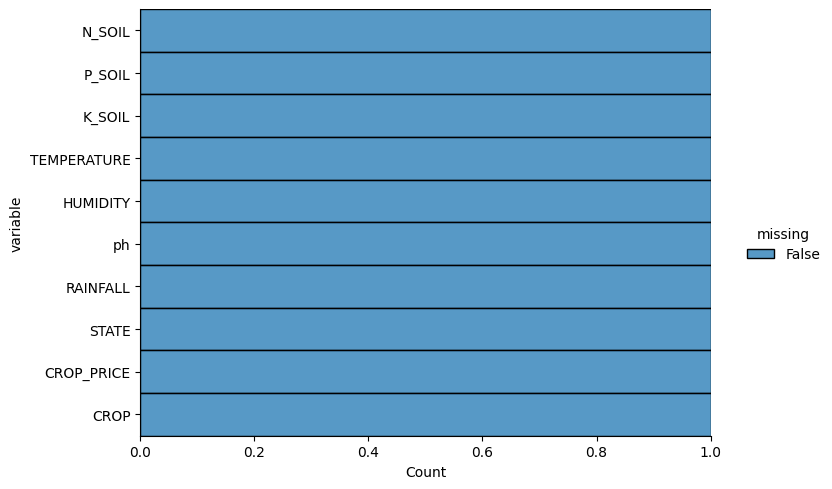

In [4]:
plt.figure(figsize=(10,6))
sns.displot(
    data=df.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.5
)

In [5]:
df=df.drop(["STATE","CROP_PRICE"],axis=1)
df.head()

,N_SOIL,P_SOIL,K_SOIL,TEMPERATURE,HUMIDITY,ph,RAINFALL,CROP
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [6]:
df.count()

N_SOIL         2200
P_SOIL         2200
K_SOIL         2200
TEMPERATURE    2200
HUMIDITY       2200
ph             2200
RAINFALL       2200
CROP           2200
dtype: int64

In [7]:
df.dtypes

N_SOIL           int64
P_SOIL           int64
K_SOIL           int64
TEMPERATURE    float64
HUMIDITY       float64
ph             float64
RAINFALL       float64
CROP            object
dtype: object

In [8]:
df=df.rename(columns={'N_SOIL':'N','P_SOIL':'P','K_SOIL':'K'})
df.head()

,N,P,K,TEMPERATURE,HUMIDITY,ph,RAINFALL,CROP
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice


In [9]:
df.shape

(2200, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   TEMPERATURE  2200 non-null   float64
 4   HUMIDITY     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   RAINFALL     2200 non-null   float64
 7   CROP         2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


**Since there is no null data so there is no need of replacinng it with mean or droping column**

In [11]:
df.columns

Index(['N', 'P', 'K', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL', 'CROP'], dtype='object')

In [12]:
df.describe()

,N,P,K,TEMPERATURE,HUMIDITY,ph,RAINFALL
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


#  Visualizing Features

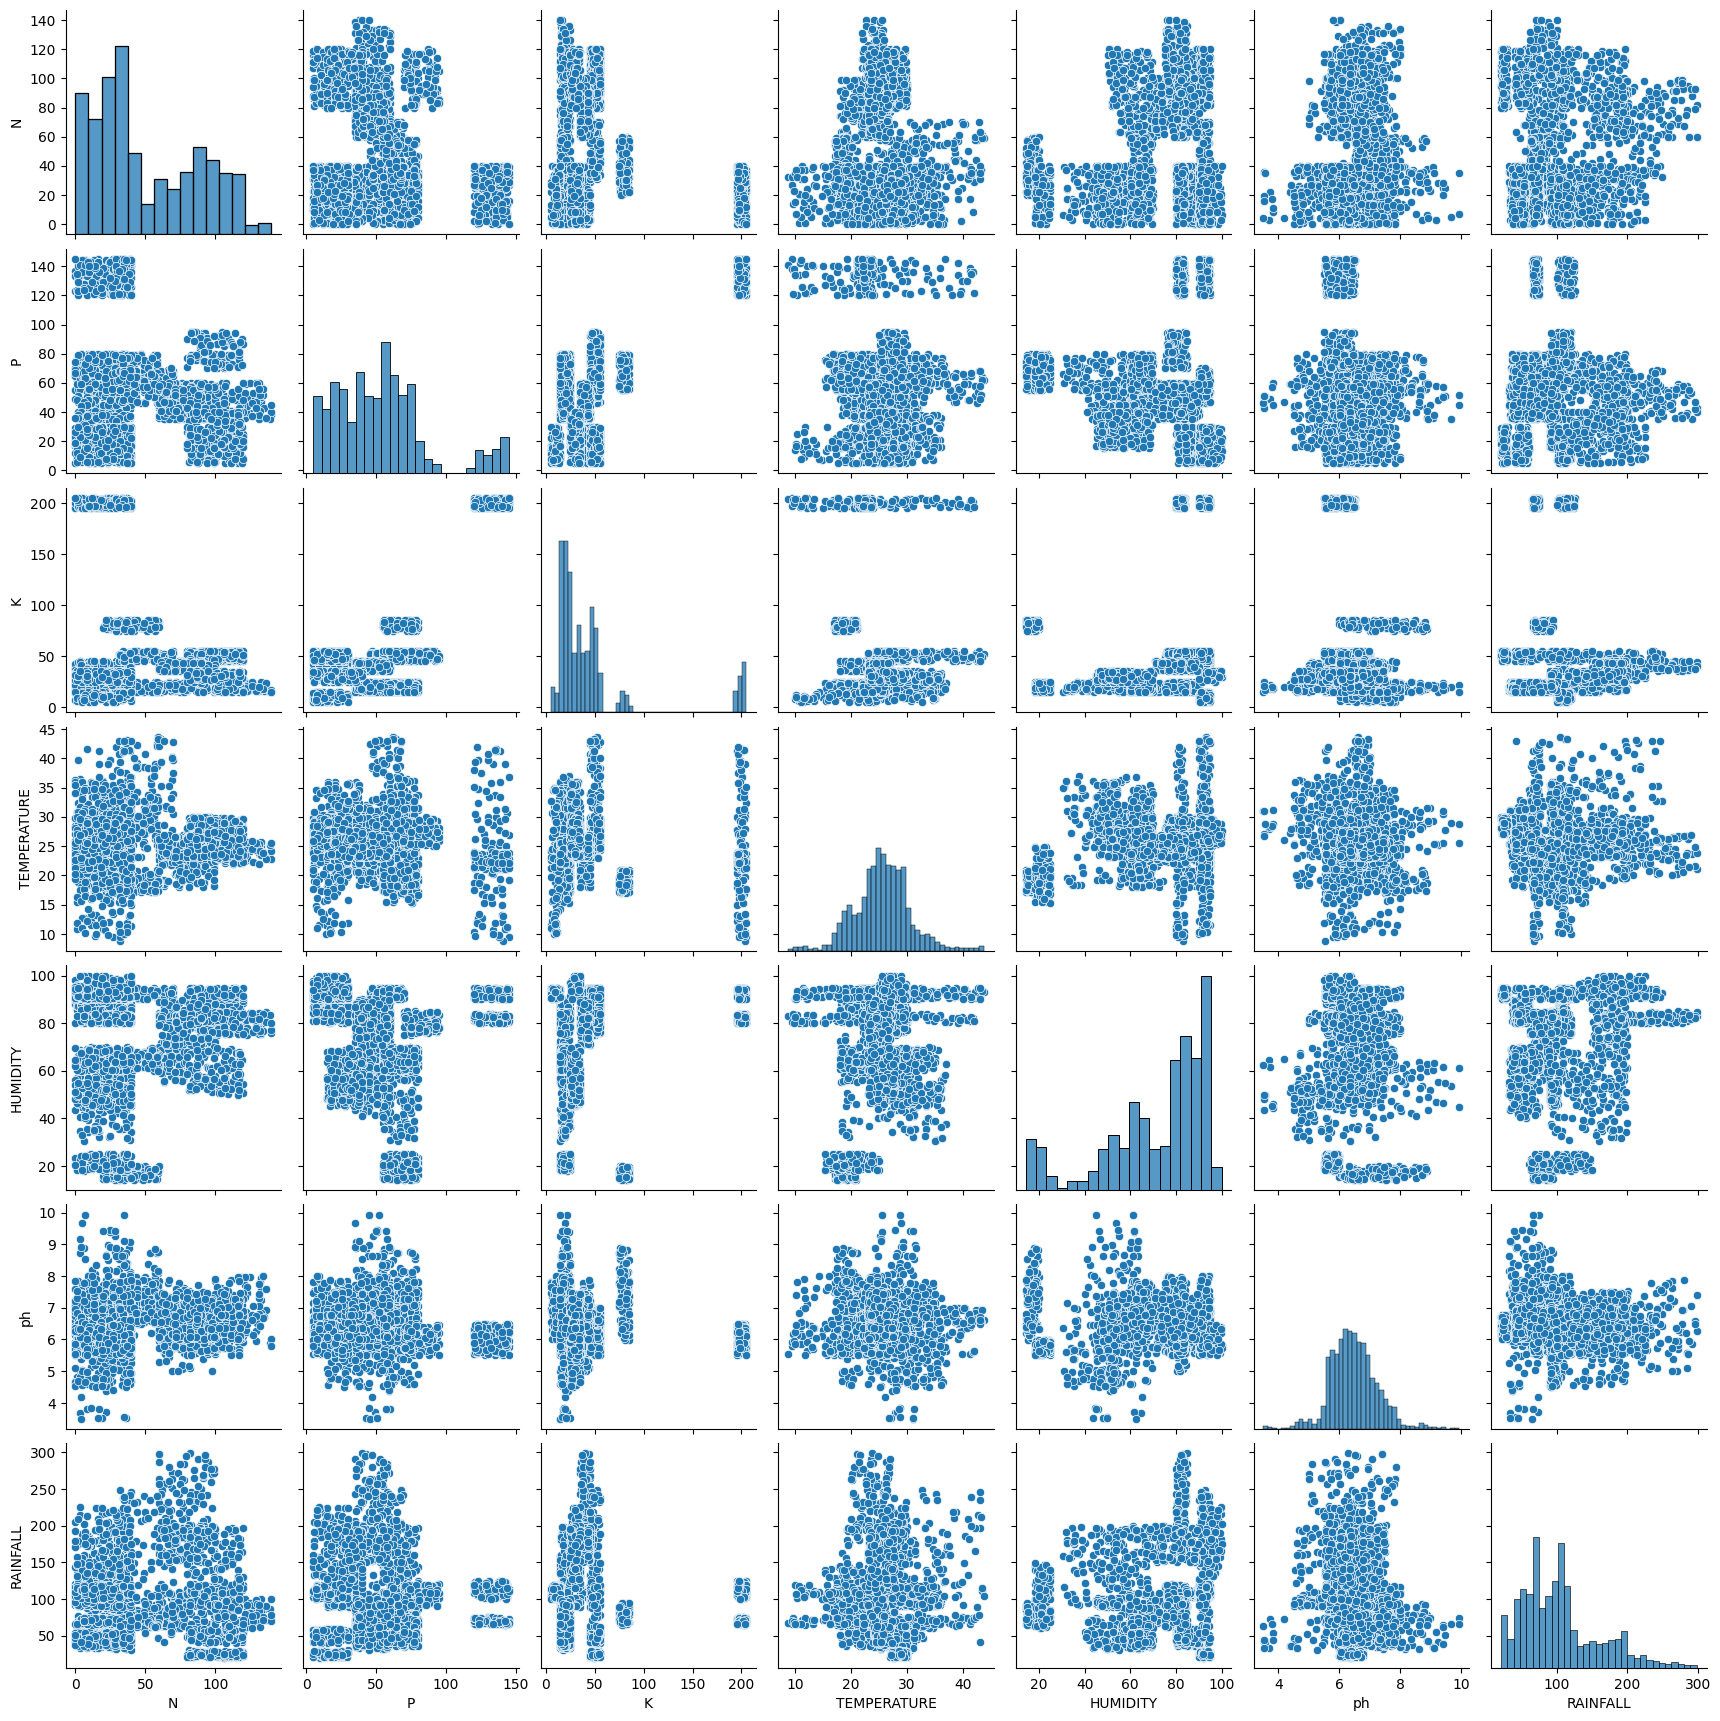

In [13]:
pair_plot=sns.pairplot(df)
plt.savefig('crop_pair_plot.png')
pair_plot

In [14]:
df.CROP.unique()

array(['Rice', 'Maize', 'ChickPea', 'KidneyBeans', 'PigeonPeas',
       'MothBeans', 'MungBean', 'Blackgram', 'Lentil', 'Pomegranate',
       'Banana', 'Mango', 'Grapes', 'Watermelon', 'Muskmelon', 'Apple',
       'Orange', 'Papaya', 'Coconut', 'Cotton', 'Jute', 'Coffee'],
      dtype=object)

In [15]:
df['CROP'].value_counts()

CROP
Rice           100
Maize          100
ChickPea       100
KidneyBeans    100
PigeonPeas     100
MothBeans      100
MungBean       100
Blackgram      100
Lentil         100
Pomegranate    100
Banana         100
Mango          100
Grapes         100
Watermelon     100
Muskmelon      100
Apple          100
Orange         100
Papaya         100
Coconut        100
Cotton         100
Jute           100
Coffee         100
Name: count, dtype: int64

In [16]:
n = 5
df['CROP'].value_counts()[:5].index.tolist()

['Rice', 'Maize', 'ChickPea', 'KidneyBeans', 'PigeonPeas']

# Bar Plot for different Features

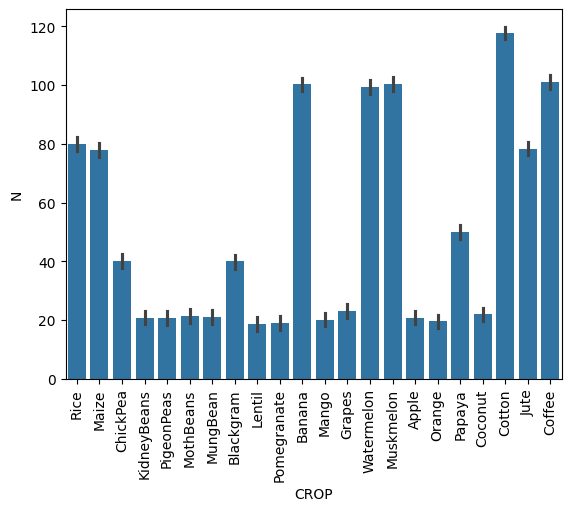

In [17]:
sns.barplot(x="CROP", y="N",data=df)
plt.xticks(rotation = 90)
plt.savefig('crop-N.png')
plt.show()

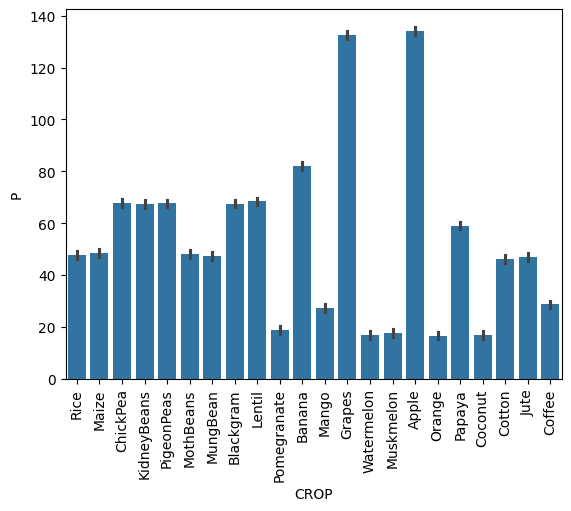

In [18]:
sns.barplot(x="CROP", y="P",data=df)
plt.xticks(rotation = 90)
plt.savefig('crop-P.png')
plt.show()

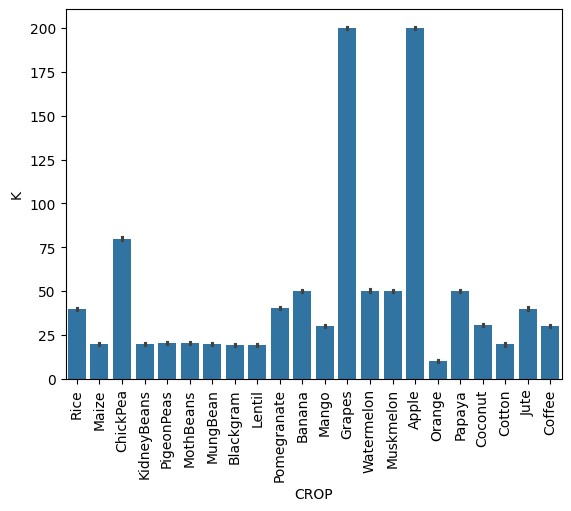

In [19]:
sns.barplot(x="CROP", y="K",data=df)
plt.xticks(rotation = 90)
plt.savefig('crop-K.png')
plt.show()

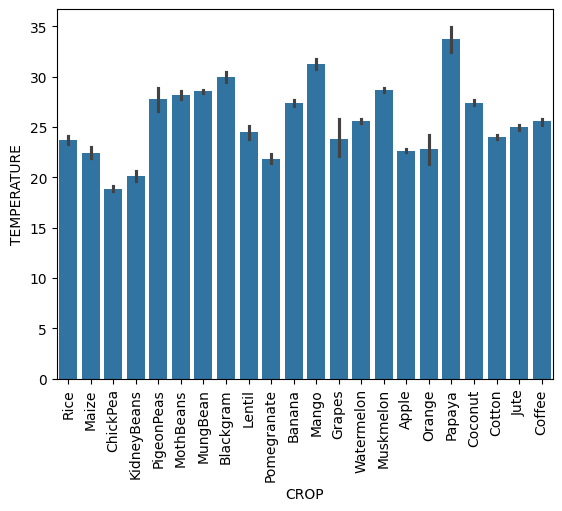

In [20]:
sns.barplot(x="CROP", y="TEMPERATURE",data=df)
plt.xticks(rotation = 90)
plt.savefig('crop-TEMPRATURE.png')
plt.show()

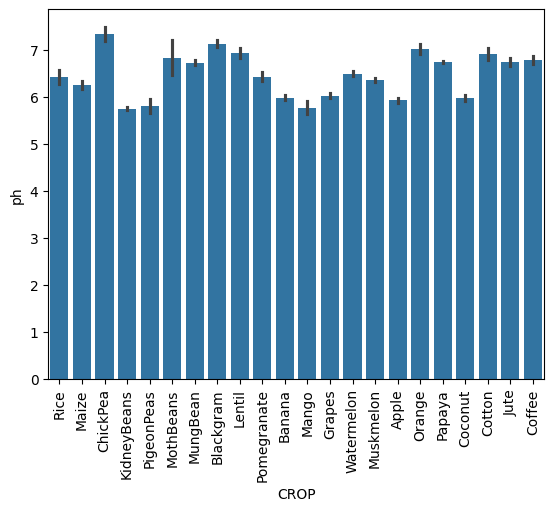

In [21]:
sns.barplot(x="CROP", y="ph",data=df)
plt.xticks(rotation = 90)
plt.savefig('crop-PH.png')
plt.show()

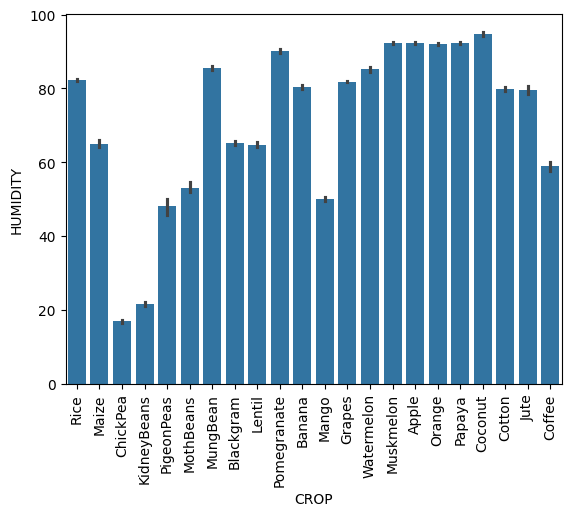

In [22]:
sns.barplot(x="CROP", y="HUMIDITY",data=df)
plt.xticks(rotation = 90)
plt.savefig('crop-HUMIDITY.png')
plt.show()

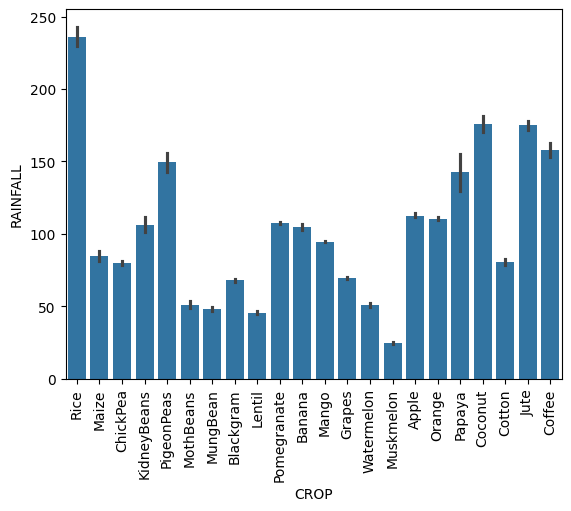

In [23]:
sns.barplot(x="CROP", y="RAINFALL",data=df)
plt.xticks(rotation = 90)
plt.savefig('crop-RAINFALL.png')
plt.show()

In [24]:
df.corr(numeric_only=True)

,N,P,K,TEMPERATURE,HUMIDITY,ph,RAINFALL
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
TEMPERATURE,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
HUMIDITY,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
RAINFALL,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

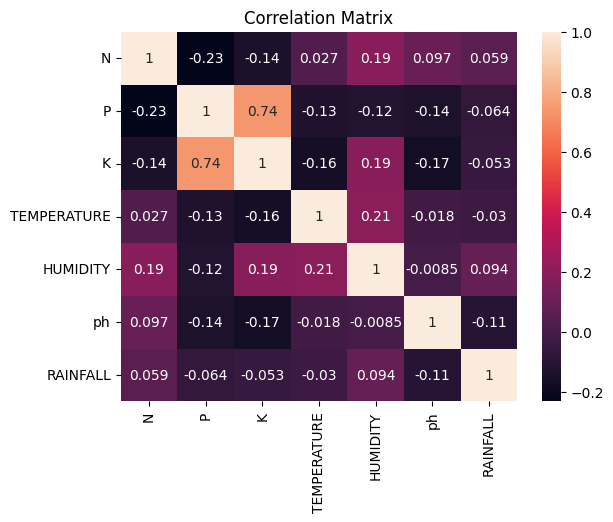

In [25]:
sns.heatmap(df.corr(numeric_only=True), annot =True)
plt.savefig('crop-corr.png')
plt.title('Correlation Matrix')

In [26]:
x=df[['N', 'P','K','TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']]
y=df["CROP"]

In [27]:
x.head()

,N,P,K,TEMPERATURE,HUMIDITY,ph,RAINFALL
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [28]:
y.head()

0    Rice
1    Rice
2    Rice
3    Rice
4    Rice
Name: CROP, dtype: object

In [29]:
y = pd.get_dummies(y)
y

,Apple,Banana,Blackgram,ChickPea,Coconut,Coffee,Cotton,Grapes,Jute,KidneyBeans,...,Mango,MothBeans,MungBean,Muskmelon,Orange,Papaya,PigeonPeas,Pomegranate,Rice,Watermelon
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2196,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2197,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2198,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [30]:
num_col = df.select_dtypes(include=[np.number])
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
model = scaler.fit(num_col)
scaled_data = model.transform(num_col)
scaled_df = pd.DataFrame(scaled_data, columns=['N', 'P', 'K', 'TEMPERATURE','HUMIDITY','ph','RAINFALL'])
scaled_df.head()

,N,P,K,TEMPERATURE,HUMIDITY,ph,RAINFALL
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373


# Classification
**Logistic Regression** <br>
**Decision Tree Classifier** <br>
**Random Forest** <br>
**K-Nearest Neighbour(KNN)** <br>
**Gaussian Naive Bayes** <br>
**Support Vector Machine** <br>
**Extra Tree Classifier(ETC)**

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

label_encoder = LabelEncoder()
df["CROP"] = label_encoder.fit_transform(df["CROP"])

X = df.drop(columns=["CROP"])
y = df["CROP"]

X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1540, 7), (660, 7), (1540,), (660,))

# Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression(max_iter=500, random_state=42)
model_LR.fit(X_train, y_train)
y_train_pred = model_LR.predict(X_train)
y_test_pred = model_LR.predict(X_test)
metrics = {
    "Accuracy": [accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)],
    "Precision": [precision_score(y_train, y_train_pred, average='weighted'), precision_score(y_test, y_test_pred, average='weighted')],
    "Recall": [recall_score(y_train, y_train_pred, average='weighted'), recall_score(y_test, y_test_pred, average='weighted')],
    "F1-score": [f1_score(y_train, y_train_pred, average='weighted'), f1_score(y_test, y_test_pred, average='weighted')]
}
metrics_df = pd.DataFrame(metrics, index=["Training", "Testing"])
metrics_df

,Accuracy,Precision,Recall,F1-score
Training,0.977922,0.978333,0.977922,0.977906
Testing,0.959091,0.960432,0.959091,0.958853


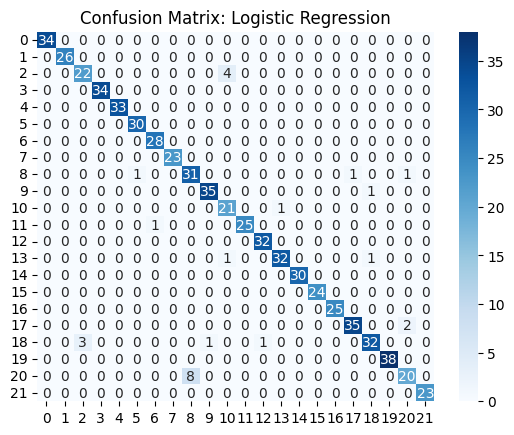

In [33]:
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression")
plt.savefig('crop-conf-LR.png')
plt.show()

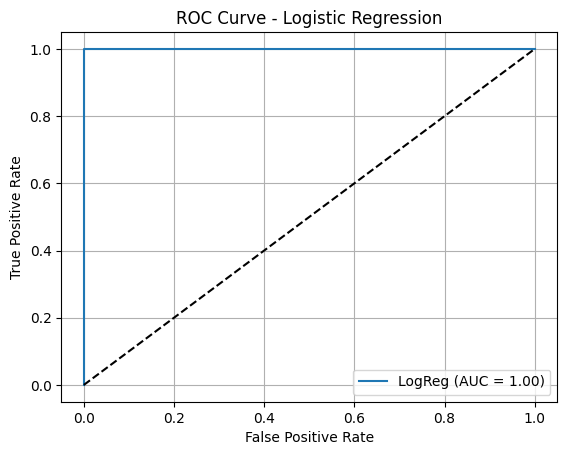

In [34]:
y_score = model_LR.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'LogReg (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('crop-roc-LR.png')
plt.show()

# Decision Tree Classifier

In [35]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)
dt_metrics = {
    "Accuracy": [accuracy_score(y_train, y_train_pred_dt), accuracy_score(y_test, y_test_pred_dt)],
    "Precision": [precision_score(y_train, y_train_pred_dt, average='weighted'), precision_score(y_test, y_test_pred_dt, average='weighted')],
    "Recall": [recall_score(y_train, y_train_pred_dt, average='weighted'), recall_score(y_test, y_test_pred_dt, average='weighted')],
    "F1-score": [f1_score(y_train, y_train_pred_dt, average='weighted'), f1_score(y_test, y_test_pred_dt, average='weighted')]
}
dt_metrics_df = pd.DataFrame(dt_metrics, index=["Training", "Testing"])
dt_metrics_df

,Accuracy,Precision,Recall,F1-score
Training,1.000000,1.000000,1.000000,1.000000
Testing,0.986364,0.986736,0.986364,0.986273


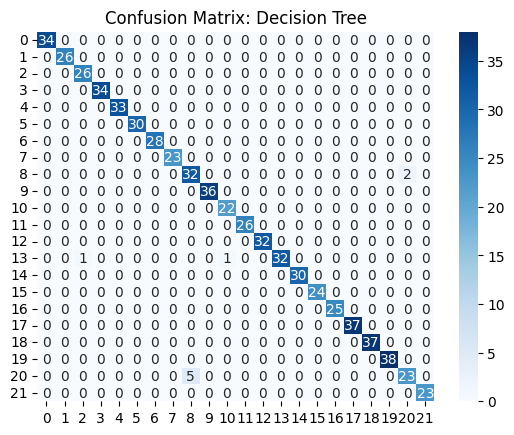

In [36]:
y_pred_dt = dt_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Decision Tree")
plt.savefig('crop-conf-DT.png')
plt.show()

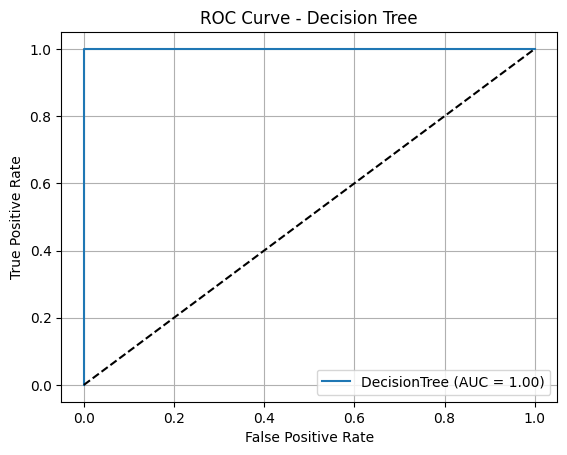

In [37]:
y_score = dt_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'DecisionTree (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('crop-roc-DT.png')
plt.show()

# Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
rf_metrics = {
    "Accuracy": [accuracy_score(y_train, y_train_pred_rf), accuracy_score(y_test, y_test_pred_rf)],
    "Precision": [precision_score(y_train, y_train_pred_rf, average='weighted'), precision_score(y_test, y_test_pred_rf, average='weighted')],
    "Recall": [recall_score(y_train, y_train_pred_rf, average='weighted'), recall_score(y_test, y_test_pred_rf, average='weighted')],
    "F1-score": [f1_score(y_train, y_train_pred_rf, average='weighted'), f1_score(y_test, y_test_pred_rf, average='weighted')]
}
rf_metrics_df = pd.DataFrame(rf_metrics, index=["Training", "Testing"])
rf_metrics_df

,Accuracy,Precision,Recall,F1-score
Training,1.000000,1.000000,1.000000,1.000000
Testing,0.992424,0.993395,0.992424,0.992312


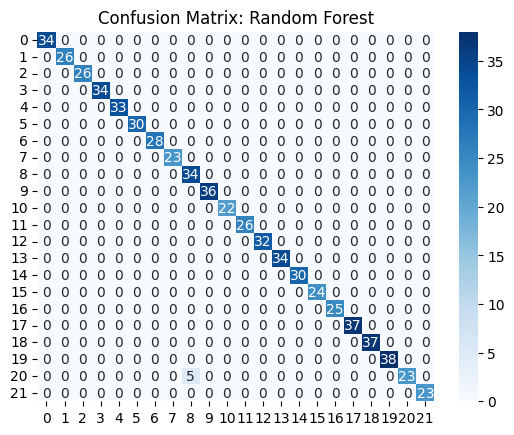

In [39]:
y_pred_rf = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Random Forest")
plt.savefig('crop-conf-RF.png')
plt.show()

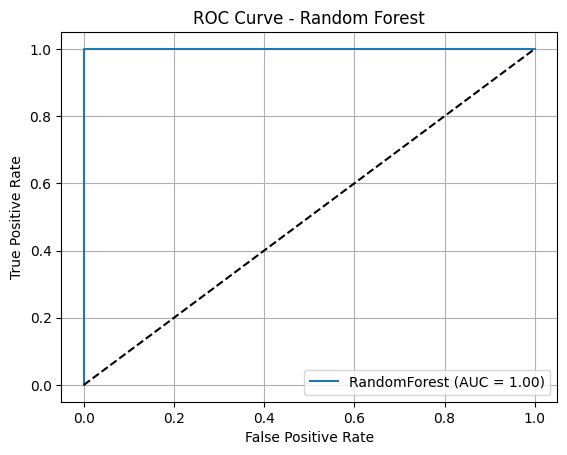

In [40]:
y_score = rf_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'RandomForest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('crop-roc-RF.png')
plt.show()

# K-Nearest Neighbour(KNN)

In [41]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)
knn_metrics = {
    "Accuracy": [accuracy_score(y_train, y_train_pred_knn), accuracy_score(y_test, y_test_pred_knn)],
    "Precision": [precision_score(y_train, y_train_pred_knn, average='weighted'), precision_score(y_test, y_test_pred_knn, average='weighted')],
    "Recall": [recall_score(y_train, y_train_pred_knn, average='weighted'), recall_score(y_test, y_test_pred_knn, average='weighted')],
    "F1-score": [f1_score(y_train, y_train_pred_knn, average='weighted'), f1_score(y_test, y_test_pred_knn, average='weighted')]
}
knn_metrics_df = pd.DataFrame(knn_metrics, index=["Training", "Testing"])
knn_metrics_df

,Accuracy,Precision,Recall,F1-score
Training,0.991558,0.991813,0.991558,0.991571
Testing,0.971212,0.974125,0.971212,0.970919


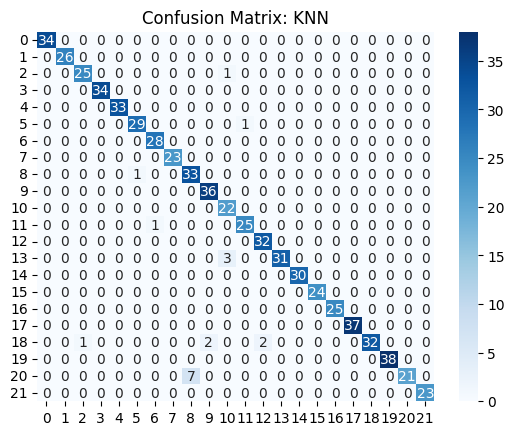

In [42]:
y_pred_knn = knn_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: KNN")
plt.savefig('crop-conf-KNN.png')
plt.show()

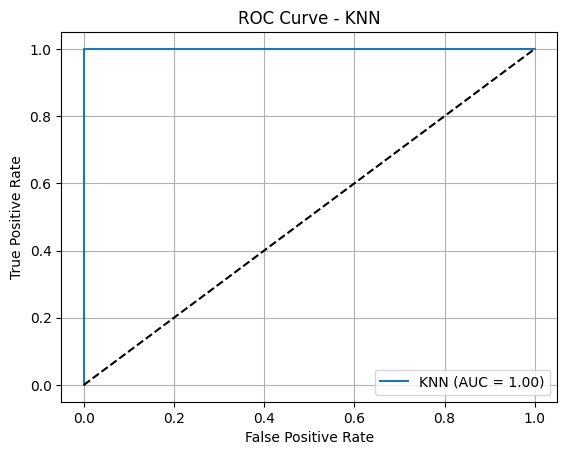

In [43]:
y_score = knn_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('crop-roc-KNN.png')
plt.show()

# Gaussian Naive Bayes

In [44]:
from sklearn.naive_bayes import GaussianNB
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
y_train_pred_gnb = gnb_model.predict(X_train)
y_test_pred_gnb = gnb_model.predict(X_test)
gnb_metrics = {
    "Accuracy": [accuracy_score(y_train, y_train_pred_gnb), accuracy_score(y_test, y_test_pred_gnb)],
    "Precision": [precision_score(y_train, y_train_pred_gnb, average='weighted'), precision_score(y_test, y_test_pred_gnb, average='weighted')],
    "Recall": [recall_score(y_train, y_train_pred_gnb, average='weighted'), recall_score(y_test, y_test_pred_gnb, average='weighted')],
    "F1-score": [f1_score(y_train, y_train_pred_gnb, average='weighted'), f1_score(y_test, y_test_pred_gnb, average='weighted')]
}
gnb_metrics_df = pd.DataFrame(gnb_metrics, index=["Training", "Testing"])
gnb_metrics_df

,Accuracy,Precision,Recall,F1-score
Training,0.995455,0.995503,0.995455,0.995456
Testing,0.993939,0.994577,0.993939,0.993875


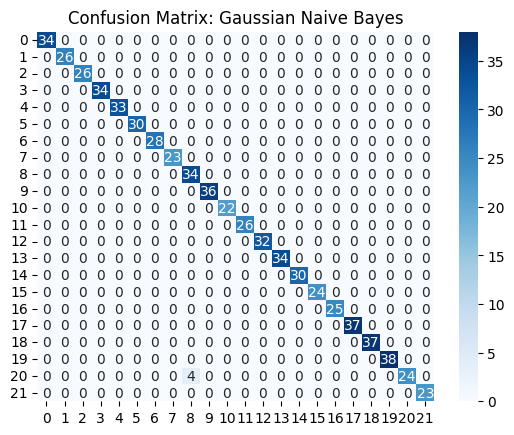

In [45]:
y_pred_gnb = gnb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Gaussian Naive Bayes")
plt.savefig('crop-conf-GNB.png')
plt.show()

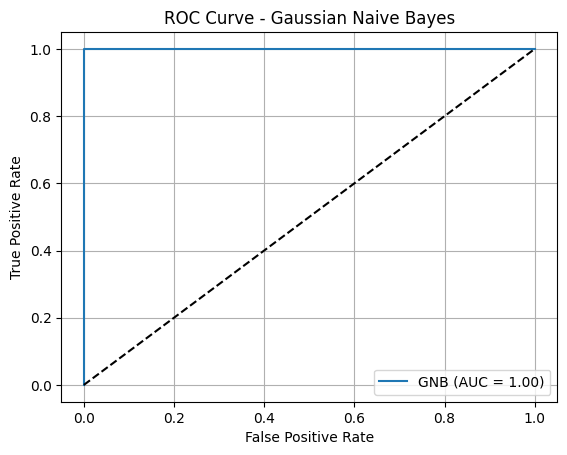

In [46]:
y_score = gnb_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'GNB (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gaussian Naive Bayes')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('crop-roc-GNB.png')
plt.show()

# Support Vector Machine

In [47]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)
svm_metrics = {
    "Accuracy": [accuracy_score(y_train, y_train_pred_svm), accuracy_score(y_test, y_test_pred_svm)],
    "Precision": [precision_score(y_train, y_train_pred_svm, average='weighted'), precision_score(y_test, y_test_pred_svm, average='weighted')],
    "Recall": [recall_score(y_train, y_train_pred_svm, average='weighted'), recall_score(y_test, y_test_pred_svm, average='weighted')],
    "F1-score": [f1_score(y_train, y_train_pred_svm, average='weighted'), f1_score(y_test, y_test_pred_svm, average='weighted')]
}
svm_metrics_df = pd.DataFrame(svm_metrics, index=["Training", "Testing"])
svm_metrics_df

,Accuracy,Precision,Recall,F1-score
Training,0.988312,0.989220,0.988312,0.988344
Testing,0.971212,0.974717,0.971212,0.970793


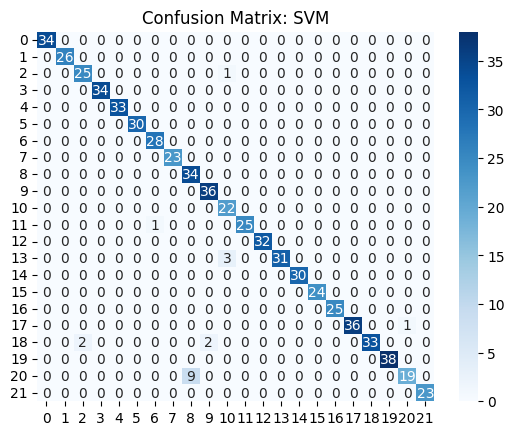

In [48]:
# Confusion Matrix
y_pred_svm = svm_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: SVM")
plt.savefig('crop-conf-SVM.png')
plt.show()

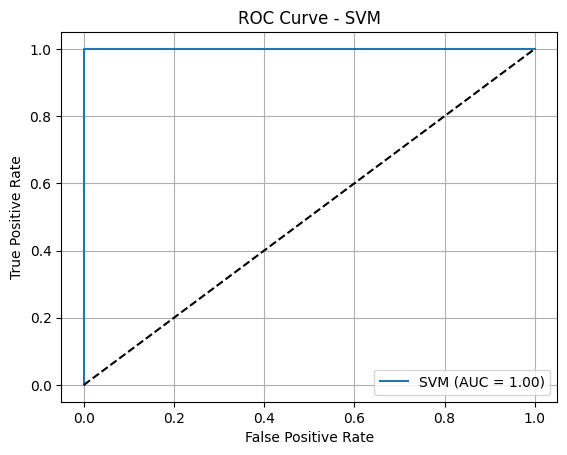

In [49]:
from sklearn.svm import SVC
svm_model = SVC(probability=True)  
svm_model.fit(X_train, y_train)
y_score = svm_model.predict_proba(X_test)  # Works now!
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'SVM (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('crop-roc-SVM.png')
plt.show()

# Extra Tree Classifier(ETC)

In [50]:
from sklearn.ensemble import ExtraTreesClassifier
etc_model = ExtraTreesClassifier(n_estimators=200, random_state=42)
etc_model.fit(X_train, y_train)
y_train_pred_etc = etc_model.predict(X_train)
y_test_pred_etc = etc_model.predict(X_test)
etc_metrics = {
    "Accuracy": [accuracy_score(y_train, y_train_pred_etc), accuracy_score(y_test, y_test_pred_etc)],
    "Precision": [precision_score(y_train, y_train_pred_etc, average='weighted'), precision_score(y_test, y_test_pred_etc, average='weighted')],
    "Recall": [recall_score(y_train, y_train_pred_etc, average='weighted'), recall_score(y_test, y_test_pred_etc, average='weighted')],
    "F1-score": [f1_score(y_train, y_train_pred_etc, average='weighted'), f1_score(y_test, y_test_pred_etc, average='weighted')]
}
etc_metrics_df = pd.DataFrame(etc_metrics, index=["Training", "Testing"])
etc_metrics_df

,Accuracy,Precision,Recall,F1-score
Training,1.000000,1.000000,1.000000,1.000000
Testing,0.986364,0.987936,0.986364,0.986296


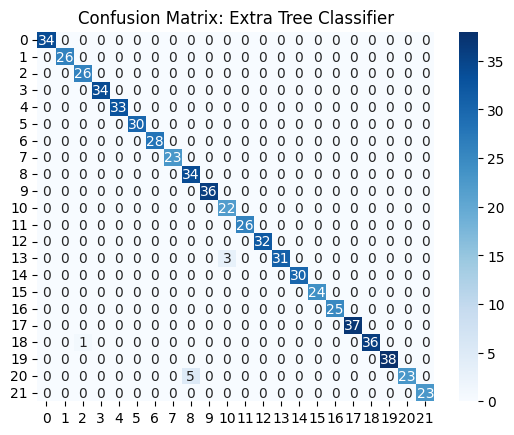

In [51]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_etc)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Extra Tree Classifier")
plt.savefig('crop-conf-ETC.png')
plt.show()

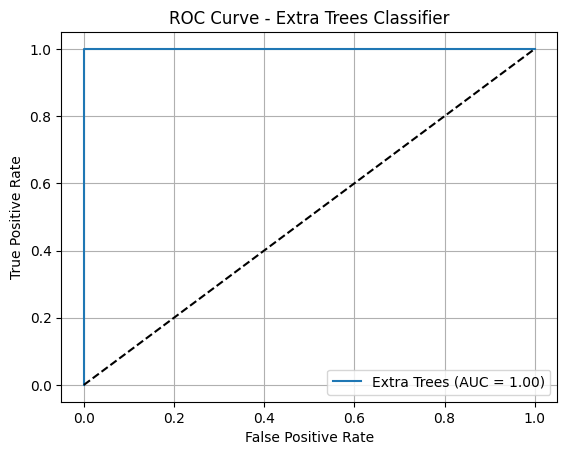

In [52]:
y_score = etc_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'Extra Trees (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Extra Trees Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('crop-roc-ETC.png')
plt.show()

# Comparison Table

In [53]:
comparison_data = {
    "Model": [
        "Extra Tree Classifier (ETC)",
        "Logistic Regression",
        "Decision Tree Classifier",
        "Random Forest",
        "K-Nearest Neighbour (KNN)",
        "Gaussian Naive Bayes",
        "Support Vector Machine (SVM)"
    ],
    "Training Accuracy": [
        etc_metrics_df.loc["Training", "Accuracy"],
        metrics_df.loc["Training", "Accuracy"],
        dt_metrics_df.loc["Training", "Accuracy"],
        rf_metrics_df.loc["Training", "Accuracy"],
        knn_metrics_df.loc["Training", "Accuracy"],
        gnb_metrics_df.loc["Training", "Accuracy"],
        svm_metrics_df.loc["Training", "Accuracy"]
    ],
    "Testing Accuracy": [
        etc_metrics_df.loc["Testing", "Accuracy"],
        metrics_df.loc["Testing", "Accuracy"],
        dt_metrics_df.loc["Testing", "Accuracy"],
        rf_metrics_df.loc["Testing", "Accuracy"],
        knn_metrics_df.loc["Testing", "Accuracy"],
        gnb_metrics_df.loc["Testing", "Accuracy"],
        svm_metrics_df.loc["Testing", "Accuracy"]
    ],
    "Training Precision": [
        etc_metrics_df.loc["Training", "Precision"],
        metrics_df.loc["Training", "Precision"],
        dt_metrics_df.loc["Training", "Precision"],
        rf_metrics_df.loc["Training", "Precision"],
        knn_metrics_df.loc["Training", "Precision"],
        gnb_metrics_df.loc["Training", "Precision"],
        svm_metrics_df.loc["Training", "Precision"]
    ],
    "Testing Precision": [
        etc_metrics_df.loc["Testing", "Precision"],
        metrics_df.loc["Testing", "Precision"],
        dt_metrics_df.loc["Testing", "Precision"],
        rf_metrics_df.loc["Testing", "Precision"],
        knn_metrics_df.loc["Testing", "Precision"],
        gnb_metrics_df.loc["Testing", "Precision"],
        svm_metrics_df.loc["Testing", "Precision"]
    ],
    "Training Recall": [
        etc_metrics_df.loc["Training", "Recall"],
        metrics_df.loc["Training", "Recall"],
        dt_metrics_df.loc["Training", "Recall"],
        rf_metrics_df.loc["Training", "Recall"],
        knn_metrics_df.loc["Training", "Recall"],
        gnb_metrics_df.loc["Training", "Recall"],
        svm_metrics_df.loc["Training", "Recall"]
    ],
    "Testing Recall": [
        etc_metrics_df.loc["Testing", "Recall"],
        metrics_df.loc["Testing", "Recall"],
        dt_metrics_df.loc["Testing", "Recall"],
        rf_metrics_df.loc["Testing", "Recall"],
        knn_metrics_df.loc["Testing", "Recall"],
        gnb_metrics_df.loc["Testing", "Recall"],
        svm_metrics_df.loc["Testing", "Recall"]
    ],
    "Training F1-score": [
        etc_metrics_df.loc["Training", "F1-score"],
        metrics_df.loc["Training", "F1-score"],
        dt_metrics_df.loc["Training", "F1-score"],
        rf_metrics_df.loc["Training", "F1-score"],
        knn_metrics_df.loc["Training", "F1-score"],
        gnb_metrics_df.loc["Training", "F1-score"],
        svm_metrics_df.loc["Training", "F1-score"]
    ],
    "Testing F1-score": [
        etc_metrics_df.loc["Testing", "F1-score"],
        metrics_df.loc["Testing", "F1-score"],
        dt_metrics_df.loc["Testing", "F1-score"],
        rf_metrics_df.loc["Testing", "F1-score"],
        knn_metrics_df.loc["Testing", "F1-score"],
        gnb_metrics_df.loc["Testing", "F1-score"],
        svm_metrics_df.loc["Testing", "F1-score"]
    ]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df.set_index("Model", inplace=True)
print("Comparison Table for Training and Testing Performance of All Models:")
comparison_df

Comparison Table for Training and Testing Performance of All Models:


,Training Accuracy,Testing Accuracy,Training Precision,Testing Precision,Training Recall,Testing Recall,Training F1-score,Testing F1-score
Model,,,,,,,,
Extra Tree Classifier (ETC),1.000000,0.986364,1.000000,0.987936,1.000000,0.986364,1.000000,0.986296
Logistic Regression,0.977922,0.959091,0.978333,0.960432,0.977922,0.959091,0.977906,0.958853
Decision Tree Classifier,1.000000,0.986364,1.000000,0.986736,1.000000,0.986364,1.000000,0.986273
Random Forest,1.000000,0.992424,1.000000,0.993395,1.000000,0.992424,1.000000,0.992312
K-Nearest Neighbour (KNN),0.991558,0.971212,0.991813,0.974125,0.991558,0.971212,0.991571,0.970919
Gaussian Naive Bayes,0.995455,0.993939,0.995503,0.994577,0.995455,0.993939,0.995456,0.993875
Support Vector Machine (SVM),0.988312,0.971212,0.989220,0.974717,0.988312,0.971212,0.988344,0.970793


# Model vs Accuracy

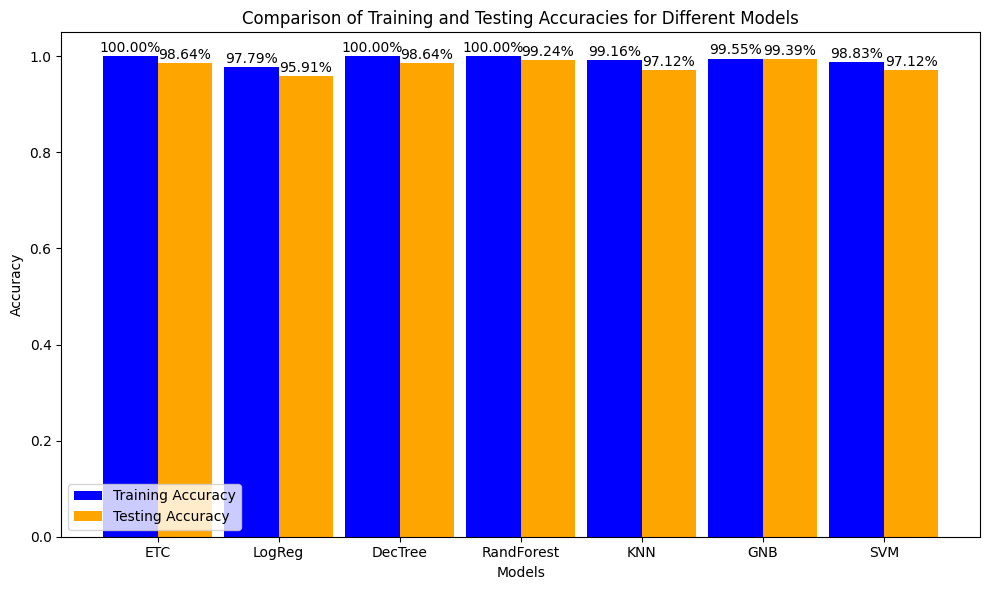

In [54]:
models = [
    "ETC", "LogReg", "DecTree", "RandForest", "KNN", "GNB", "SVM"
]
training_accuracies = [
    etc_metrics_df.loc["Training", "Accuracy"],
    metrics_df.loc["Training", "Accuracy"],
    dt_metrics_df.loc["Training", "Accuracy"],
    rf_metrics_df.loc["Training", "Accuracy"],
    knn_metrics_df.loc["Training", "Accuracy"],
    gnb_metrics_df.loc["Training", "Accuracy"],
    svm_metrics_df.loc["Training", "Accuracy"]
]
testing_accuracies = [
    etc_metrics_df.loc["Testing", "Accuracy"],
    metrics_df.loc["Testing", "Accuracy"],
    dt_metrics_df.loc["Testing", "Accuracy"],
    rf_metrics_df.loc["Testing", "Accuracy"],
    knn_metrics_df.loc["Testing", "Accuracy"],
    gnb_metrics_df.loc["Testing", "Accuracy"],
    svm_metrics_df.loc["Testing", "Accuracy"]
]
x = range(len(models))
width = 0.45
fig, ax = plt.subplots(figsize=(10, 6))
bar1 = ax.bar([i - width / 2 for i in x], training_accuracies, width, label='Training Accuracy', color='blue')
bar2 = ax.bar([i + width / 2 for i in x], testing_accuracies, width, label='Testing Accuracy', color='orange')
ax.set_xlabel('Models')
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of Training and Testing Accuracies for Different Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('train-test_accuracy_comp.png')
plt.show()

## k-fold Cross Validation

In [55]:
from sklearn.model_selection import cross_val_score, KFold
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbour (KNN)': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'Extra Tree Classifier (ETC)': ExtraTreesClassifier()
}

In [56]:
kf = KFold(n_splits=3, shuffle=True, random_state=42) # k=3
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    results[name] = [scores.mean()]
results_df = pd.DataFrame(results, index=['k=3']).T
results_df.columns = ['Score']
results_df

,Score
Logistic Regression,0.965458
Decision Tree Classifier,0.983640
Random Forest,0.995910
K-Nearest Neighbour (KNN),0.980002
Gaussian Naive Bayes,0.995455
Support Vector Machine,0.975914
Extra Tree Classifier (ETC),0.991820


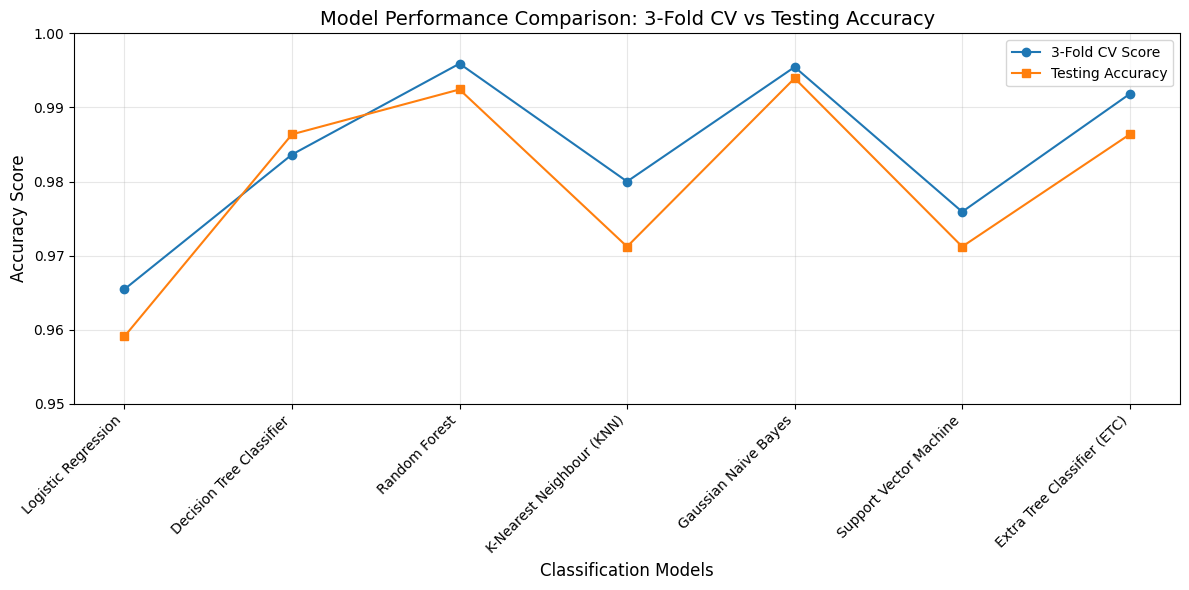

In [57]:
testing_acc = [0.959091, 0.986364, 0.992424, 0.971212, 0.993939, 0.971212, 0.986364]
comparison_df = pd.DataFrame({
    '3-Fold CV': results_df['Score'],
    'Testing Accuracy': testing_acc
}, index=models.keys())
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['3-Fold CV'], 
         marker='o', label='3-Fold CV Score', color='#1f77b4')
plt.plot(comparison_df.index, comparison_df['Testing Accuracy'], 
         marker='s', label='Testing Accuracy', color='#ff7f0e')
plt.title('Model Performance Comparison: 3-Fold CV vs Testing Accuracy', fontsize=14)
plt.xlabel('Classification Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.95, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('BP-16.png')
plt.show()

# Crop Predictive System

In [58]:
print("LabelCode     Crop Name")
for idx, name in enumerate(label_encoder.classes_):
    print(f"{idx:<12} -> {name}")

LabelCode     Crop Name
0            -> Apple
1            -> Banana
2            -> Blackgram
3            -> ChickPea
4            -> Coconut
5            -> Coffee
6            -> Cotton
7            -> Grapes
8            -> Jute
9            -> KidneyBeans
10           -> Lentil
11           -> Maize
12           -> Mango
13           -> MothBeans
14           -> MungBean
15           -> Muskmelon
16           -> Orange
17           -> Papaya
18           -> PigeonPeas
19           -> Pomegranate
20           -> Rice
21           -> Watermelon


# Ensemble Learning

In [59]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
ensemble = VotingClassifier(
    estimators=[
        ('etc', etc_model),
        ('rf', rf_model),
        ('knn', knn_model),
        ('gnb', gnb_model),
        ('svm', svm_model)
    ],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_train_pred = ensemble.predict(X_train)
y_test_pred = ensemble.predict(X_test)

print("Ensemble Performance:")
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))

Ensemble Performance:

Training Accuracy: 0.9993506493506493
Testing Accuracy: 0.9863636363636363


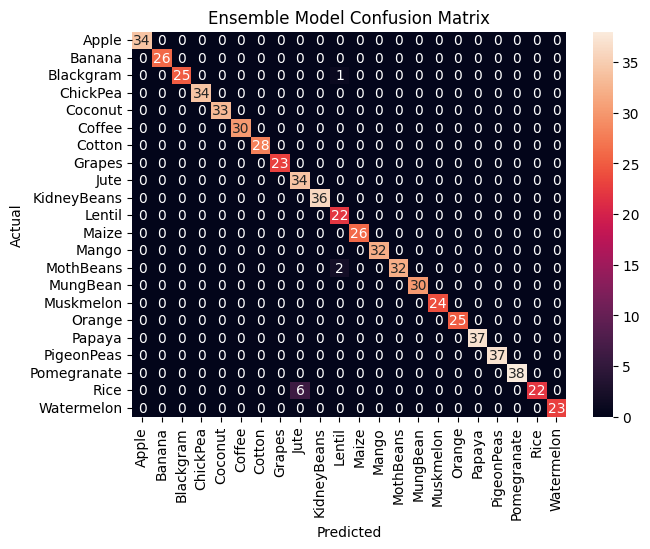

In [60]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), 
            annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Ensemble Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('crop-conf-Ensemble.png')
plt.show()

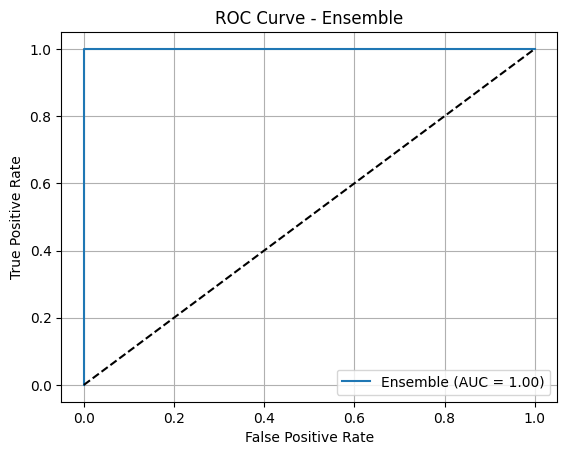

In [61]:
y_score = ensemble.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=1)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Ensemble')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('crop-roc-Ensemble.png')
plt.show()

In [62]:
import pickle
with open('ensemble_model.pkl', 'wb') as file:
    pickle.dump(ensemble, file)

In [63]:
with open('scaler1.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [64]:
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)

In [65]:
import joblib
import pandas as pd

model = joblib.load('ensemble_model.pkl') 
scaler = joblib.load('scaler1.pkl')
label_encoder = joblib.load('label_encoder.pkl')

def predict_production():
    print("\nEnter soil details:")
    features = [
        int(input("Nitrogen (N): ")),
        int(input("Phosphorus (P): ")),
        int(input("Potassium (K): ")),
        float(input("Temperature: ")),
        float(input("Humidity: ")),
        float(input("pH: ")),
        float(input("Rainfall: ")),
    ]
    input_data = pd.DataFrame([features], columns=[
        'N', 'P', 'K', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL'
    ])
    scaled_input = scaler.transform(input_data)
    predicted_label = model.predict(scaled_input)[0]
    predicted_crop_name = label_encoder.inverse_transform([predicted_label])[0]
    
    print(f"\nCrop Recommended: {predicted_crop_name}")
while True:
    predict_production()
    if input("\nPredict again? (y/n): ").lower() != 'y':
        break


Enter soil details:


Nitrogen (N):  98
Phosphorus (P):  46
Potassium (K):  43
Temperature:  21.2
Humidity:  36.14
pH:  6.3
Rainfall:  187



Crop Recommended: Coffee



Predict again? (y/n):  n



Predict again? (y/n):  n


# XAI

In [66]:
feature_names = ['N', 'P', 'K', 'TEMPERATURE', 'HUMIDITY', 'ph', 'RAINFALL']
target_name = 'CROP'
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

In [67]:
import lime
import lime.lime_tabular
from lime import submodular_pick
from sklearn.inspection import permutation_importance

In [68]:
print("\nLIME Explanations:")
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=label_encoder.classes_,
    mode='classification',
    verbose=True,
    discretize_continuous=True
)
idx = np.random.randint(0, len(X_test))
exp = explainer.explain_instance(
    data_row=X_test.iloc[idx], 
    predict_fn=ensemble.predict_proba,
    num_features=10,
    top_labels=3
)
print()
print(f"Explanation for instance {idx}: True class = {label_encoder.inverse_transform([y_test.iloc[idx]])[0]}")
exp.show_in_notebook(show_table=True)


LIME Explanations:
Intercept 0.03474429108183144
Prediction_local [0.09446695]
Right: 0.005631120879274444
Intercept 0.006590982891707231
Prediction_local [0.11009565]
Right: 0.04639209749874525
Intercept -0.023933006446374798
Prediction_local [0.26507405]
Right: 0.9232717105406243

Explanation for instance 227: True class = Pomegranate


In [69]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=ensemble.classes_,
    mode='classification',
    random_state=42
)

In [70]:
# Choose an instance to explain (for example, the first test instance)
instance_idx = 0
instance = X_test.iloc[instance_idx]

# Generate the explanation
explanation = explainer.explain_instance(
    instance.values, 
    ensemble.predict_proba,
    num_features=len(feature_names)
)

# Visualize the explanation
explanation.show_in_notebook()

In [71]:
from sklearn.inspection import permutation_importance
def get_feature_importance(model, X, y, model_name, feature_names):
    if hasattr(model, 'feature_importances_'):
        return pd.Series(model.feature_importances_, index=feature_names)
    else:
        result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
        return pd.Series(result.importances_mean, index=feature_names)
etc_importance = get_feature_importance(etc_model, X_train, y_train, 'ExtraTrees', feature_names)
rf_importance = get_feature_importance(rf_model, X_train, y_train, 'RandomForest', feature_names)
knn_importance = get_feature_importance(knn_model, X_train, y_train, 'KNN', feature_names)
gnb_importance = get_feature_importance(gnb_model, X_train, y_train, 'GaussianNB', feature_names)
svm_importance = get_feature_importance(svm_model, X_train, y_train, 'SVM', feature_names)

In [72]:
importance_df = pd.DataFrame({
    'ExtraTrees': etc_importance,
    'RandomForest': rf_importance,
    'KNN': knn_importance,
    'GaussianNB': gnb_importance,
    'SVM': svm_importance
})
importance_df

,ExtraTrees,RandomForest,KNN,GaussianNB,SVM
N,0.115119,0.100548,0.316818,0.151623,0.317792
P,0.142089,0.156440,0.200584,0.178182,0.237013
K,0.186057,0.177479,0.164610,0.428052,0.196364
TEMPERATURE,0.085672,0.076226,0.166818,0.081818,0.117857
HUMIDITY,0.209823,0.206435,0.343896,0.445779,0.360714
ph,0.058535,0.055558,0.107792,0.046234,0.062273
RAINFALL,0.202705,0.227314,0.340390,0.357468,0.362987


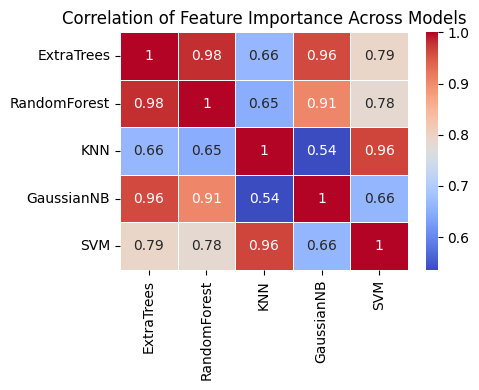

In [73]:
plt.figure(figsize=(5,4))
correlation_matrix = importance_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation of Feature Importance Across Models')
plt.tight_layout()
plt.savefig('feature_importance_correlation.png')
plt.show()

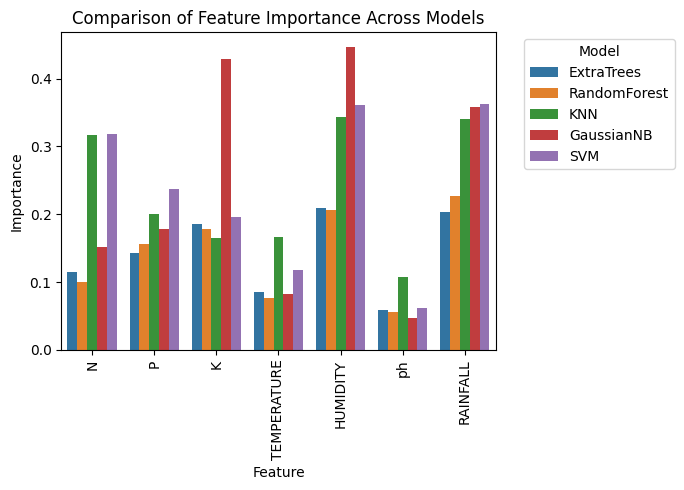

In [74]:
importance_df_melted = importance_df.reset_index().melt(
    id_vars='index', 
    value_vars=importance_df.columns, 
    var_name='Model', 
    value_name='Importance'
)
importance_df_melted.rename(columns={'index': 'Feature'}, inplace=True)
plt.figure(figsize=(7,5))
sns.barplot(x='Feature', y='Importance', hue='Model', data=importance_df_melted)
plt.xticks(rotation=90)
plt.title('Comparison of Feature Importance Across Models')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('BP-9.png')
plt.show()

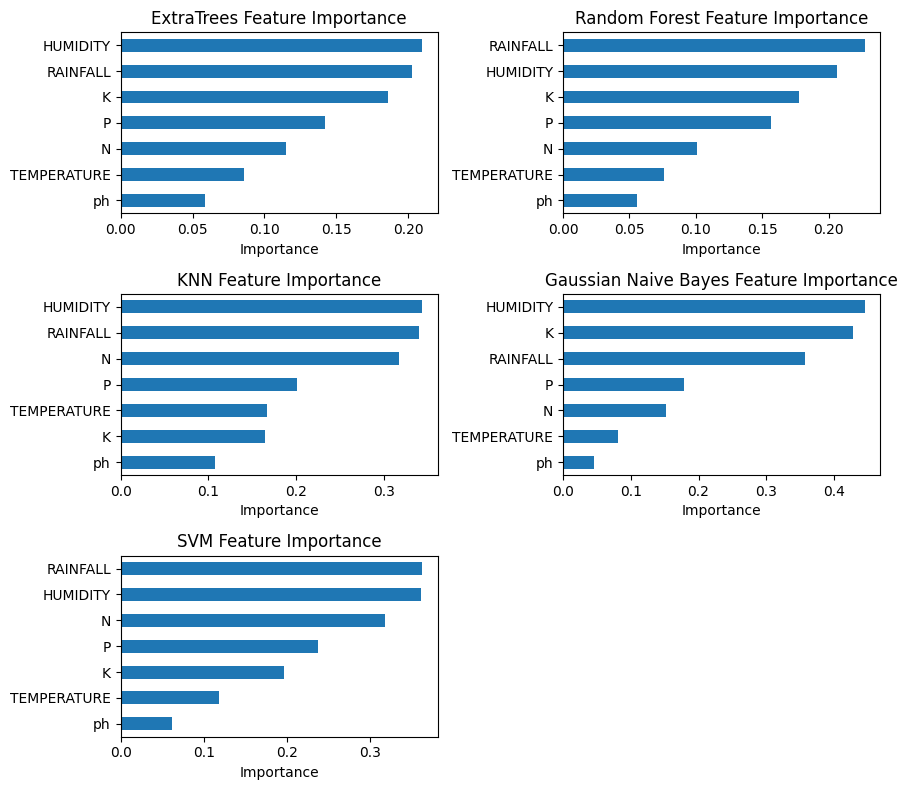

In [75]:
fig, axes = plt.subplots(3, 2, figsize=(9,8))
axes = axes.flatten()
def plot_feature_importance(importance, title, ax):
    importance.sort_values().plot(kind='barh', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Importance')
plot_feature_importance(etc_importance, 'ExtraTrees Feature Importance', axes[0])
plot_feature_importance(rf_importance, 'Random Forest Feature Importance', axes[1])
plot_feature_importance(knn_importance, 'KNN Feature Importance', axes[2])
plot_feature_importance(gnb_importance, 'Gaussian Naive Bayes Feature Importance', axes[3])
plot_feature_importance(svm_importance, 'SVM Feature Importance', axes[4])
axes[5].set_visible(False)
plt.tight_layout()
plt.savefig('individual_feature_importance.png')
plt.show()

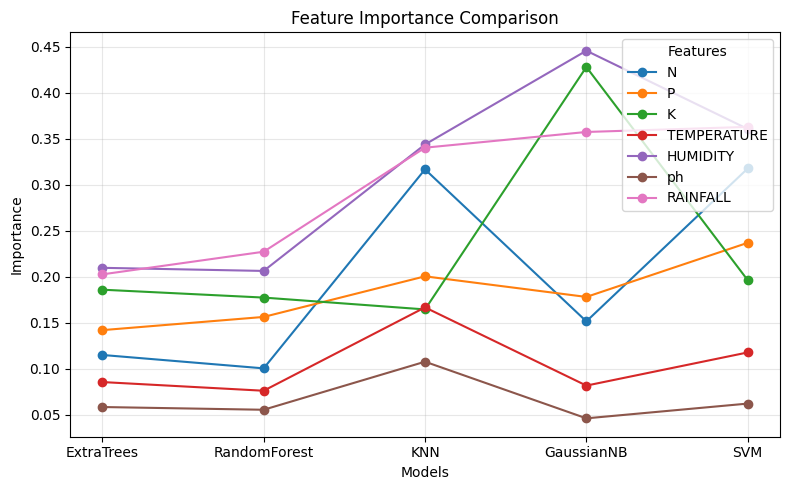

In [76]:
def get_feature_importance(model, X, y, feature_names):
    if hasattr(model, 'feature_importances_'):
        return pd.Series(model.feature_importances_, index=feature_names)
    else:
        result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
        return pd.Series(result.importances_mean, index=feature_names)
plt.figure(figsize=(8,5))
plt.grid(True, alpha=0.3)
for feature in importance_df.index:
    plt.plot(importance_df.columns, importance_df.loc[feature], marker='o', label=feature)
plt.xlabel('Models')
plt.ylabel('Importance')
plt.title('Feature Importance Comparison')
plt.legend(title='Features', loc='upper right')
plt.tight_layout()
plt.savefig('BP-10.png')
plt.show()

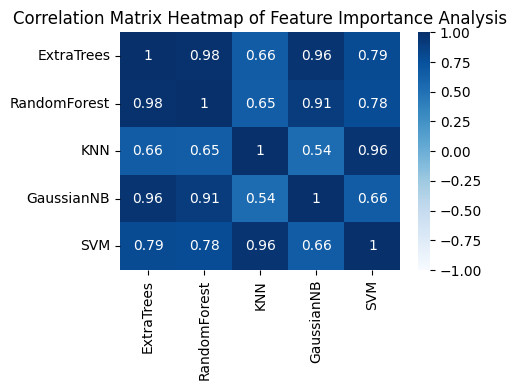

In [77]:
correlation_matrix = importance_df.corr()
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap of Feature Importance Analysis')
plt.tight_layout()
plt.savefig('feature_importance_correlation.png')
plt.show()

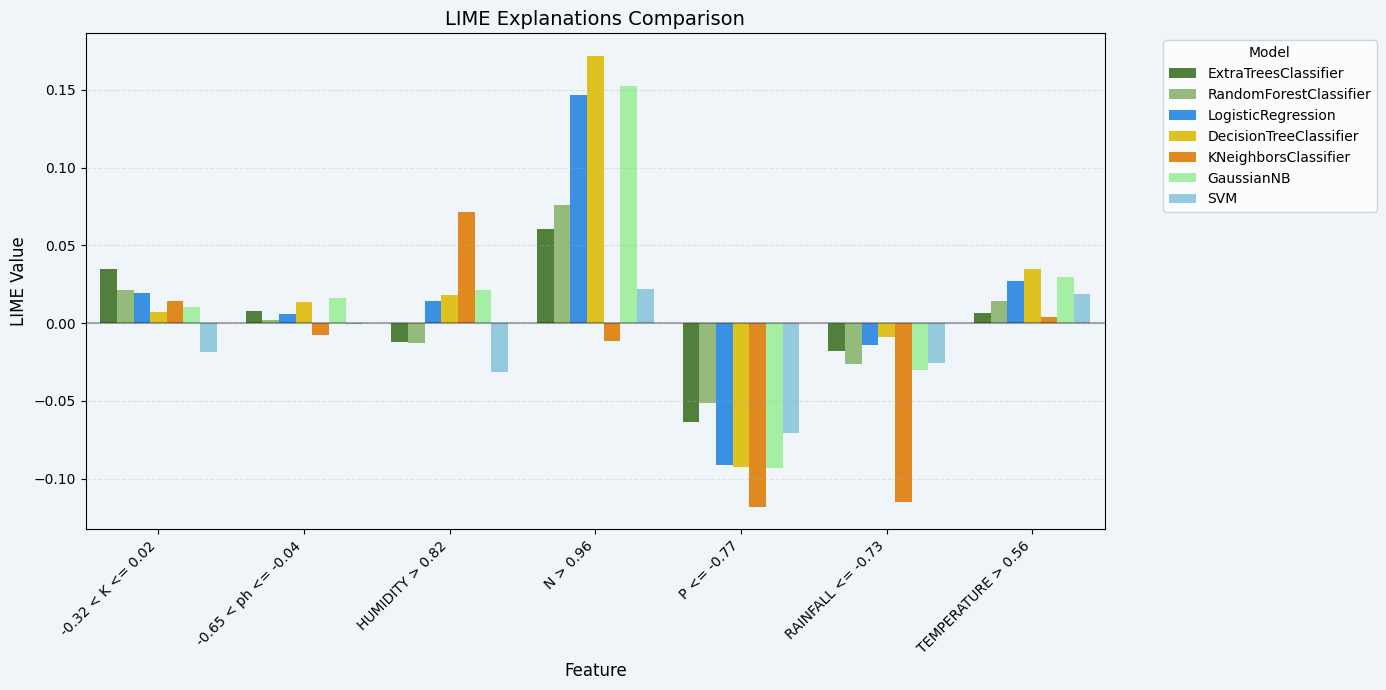

In [78]:
def plot_lime_explanations_comparison(X_train, X_test, models, model_names, feature_names, class_names, instance_idx=0, num_features=None):
    instance = X_test.iloc[instance_idx].values
    feature_conditions = set()
    all_explanations = {}
    for model, name in zip(models, model_names):
        explanation = explainer.explain_instance(
            instance, 
            model.predict_proba,
            num_features=num_features or len(feature_names)
        )
        exp_list = explanation.as_list()
        for feat_cond, _ in exp_list:
            feature_conditions.add(feat_cond)
        all_explanations[name] = {feat_cond: weight for feat_cond, weight in exp_list}
    feature_conditions = sorted(list(feature_conditions))
    exp_df = pd.DataFrame(index=feature_conditions, columns=model_names)
    for model_name, exp_dict in all_explanations.items():
        for feat_cond, weight in exp_dict.items():
            exp_df.loc[feat_cond, model_name] = weight
    exp_df.fillna(0, inplace=True)
    
    plt.figure(figsize=(14, 7))
    ax = plt.gca()
    ax.set_facecolor('#f0f5fa')  # Light blue/grey background
    plt.gcf().set_facecolor('#f0f5fa')
    
    melted_df = exp_df.reset_index().melt(
        id_vars='index',
        var_name='Model',
        value_name='LIME Value'
    )
    melted_df.rename(columns={'index': 'Feature'}, inplace=True)
    palette = {
        'ExtraTreesClassifier': '#4D8B31',    # Dark green
        'RandomForestClassifier': '#93c572',   # Medium green
        'LogisticRegression': '#1E90FF',       # Blue
        'DecisionTreeClassifier': '#FFD700',   # Gold
        'KNeighborsClassifier': '#FF8C00',     # Orange
        'GaussianNB': '#98FB98',               # Light green
        'SVM': '#87CEEB'                       # Light blue
    }
    sns.barplot(
        x='Feature', 
        y='LIME Value', 
        hue='Model', 
        data=melted_df,
        palette=palette,
        ax=ax
    )
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.title('LIME Explanations Comparison', fontsize=14)
    plt.xlabel('Feature', fontsize=12)
    plt.ylabel('LIME Value', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    return plt

if __name__ == "__main__":
    models = [etc_model, rf_model, model_LR , model_LR,dt_model, knn_model, gnb_model, svm_model]
    model_names = ['ExtraTreesClassifier','RandomForestClassifier','LogisticRegression','DecisionTreeClassifier','KNeighborsClassifier', 'GaussianNB', 'SVM']
    feature_names = X_train.columns.tolist()
    class_names = np.unique(y_train)
    plot = plot_lime_explanations_comparison(
        X_train, X_test, models, model_names, 
        feature_names, class_names,
        instance_idx=0,
        num_features=8
    )    
    plt.savefig('BP-13.png', dpi=300, bbox_inches='tight')
    plt.show()

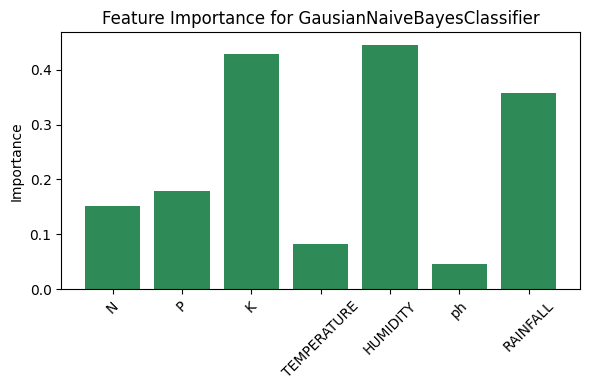

In [79]:
plt.figure(figsize=(6,4))
plt.bar(feature_names, gnb_importance, color='seagreen')
plt.title('Feature Importance for GausianNaiveBayesClassifier')
plt.xticks(rotation=45)
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('BP-14.png')
plt.show()

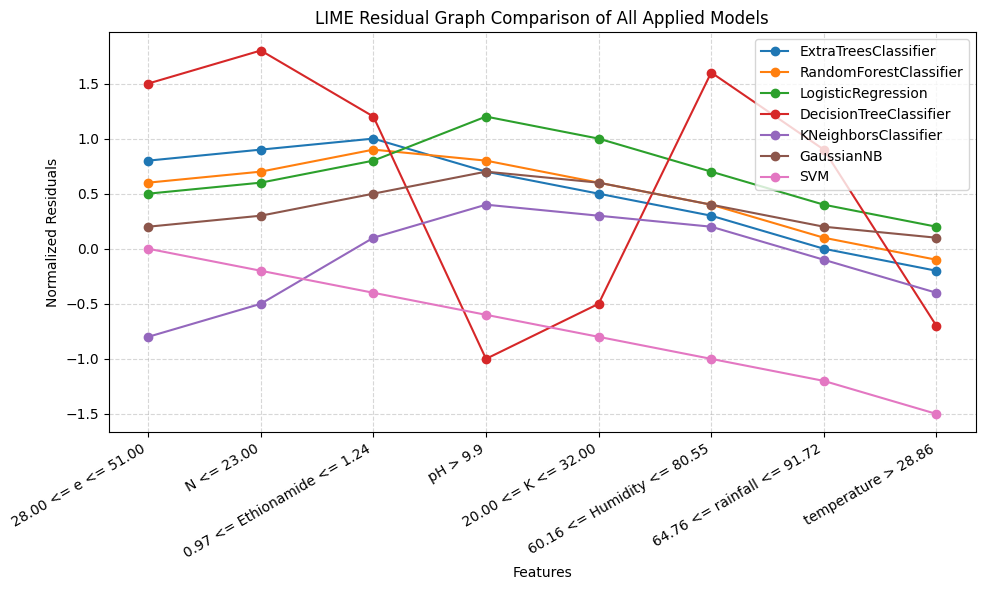

In [80]:
features = [
    '28.00 <= e <= 51.00', 'N <= 23.00', '0.97 <= Ethionamide <= 1.24', 
    'pH > 9.9', '20.00 <= K <= 32.00', '60.16 <= Humidity <= 80.55', 
    '64.76 <= rainfall <= 91.72', 'temperature > 28.86'
]
residuals = np.array([
    [ 0.8,  0.9,  1.0,  0.7,  0.5,  0.3,  0.0, -0.2],  # ExtraTreesClassifier
    [ 0.6,  0.7,  0.9,  0.8,  0.6,  0.4,  0.1, -0.1],  # RandomForestClassifier
    [ 0.5,  0.6,  0.8,  1.2,  1.0,  0.7,  0.4,  0.2],  # LogisticRegression
    [ 1.5,  1.8,  1.2, -1.0, -0.5,  1.6,  0.9, -0.7],  # DecisionTreeClassifier
    [-0.8, -0.5,  0.1,  0.4,  0.3,  0.2, -0.1, -0.4],  # KNeighborsClassifier
    [ 0.2,  0.3,  0.5,  0.7,  0.6,  0.4,  0.2,  0.1],  # GaussianNB
    [ 0.0, -0.2, -0.4, -0.6, -0.8, -1.0, -1.2, -1.5],  # SVM
])
model_names = [
    'ExtraTreesClassifier', 'RandomForestClassifier', 'LogisticRegression',
    'DecisionTreeClassifier', 'KNeighborsClassifier', 'GaussianNB', 'SVM'
]
plt.figure(figsize=(10, 6))
for i, model in enumerate(model_names):
    plt.plot(features, residuals[i], marker='o', label=model)
plt.title('LIME Residual Graph Comparison of All Applied Models')
plt.xlabel('Features')
plt.ylabel('Normalized Residuals')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('BP-12.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()